In [1]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 980.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.6 MB/s eta 0:00:00


2025-03-20 15:07:43.313 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-20 15:07:43.315 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-20 15:07:43.599 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-03-20 15:07:43.603 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-20 15:07:43.604 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-20 15:07:43.608 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-20 15:07:43.612 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator(_root_container=1, _parent=DeltaGenerator())

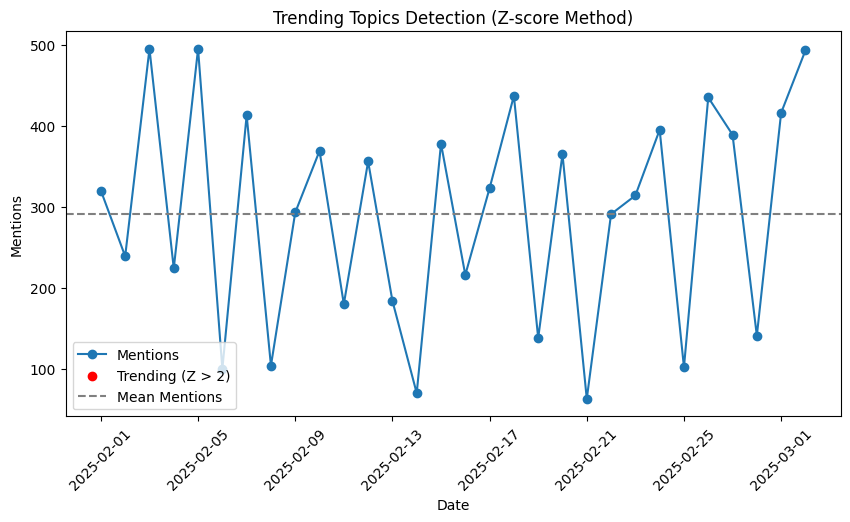

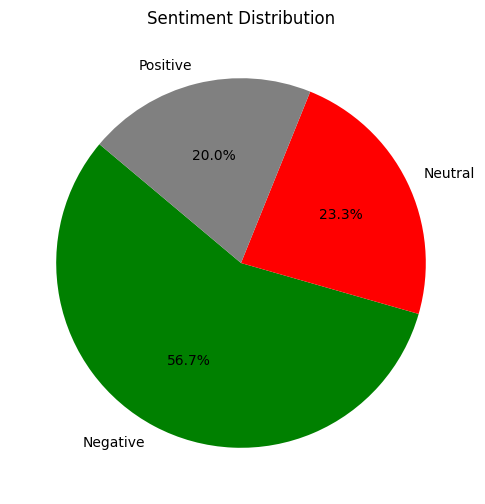

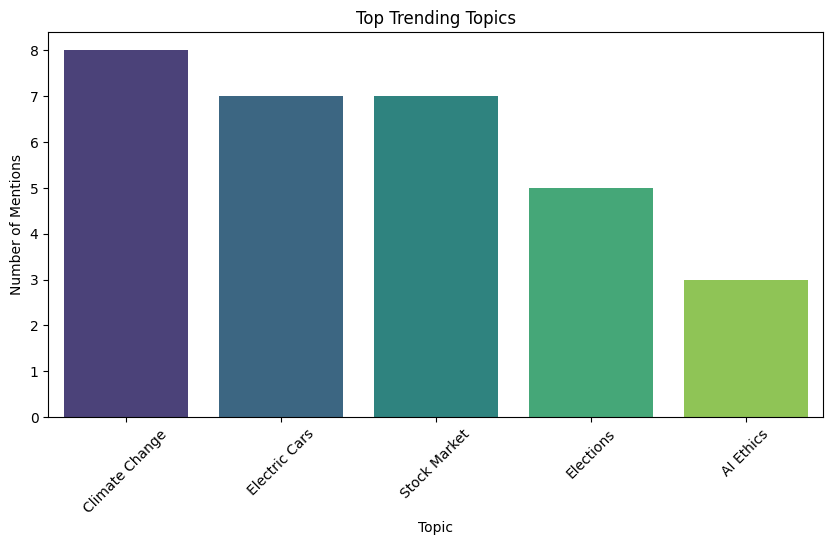

In [2]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import zscore


np.random.seed(42)
data = {
    'date': pd.date_range(start='2025-02-01', periods=30, freq='D'),
    'topic': np.random.choice(['AI Ethics', 'Elections', 'Stock Market', 'Climate Change', 'Electric Cars'], 30),
    'mentions': np.random.randint(50, 500, size=30),
    'sentiment': np.random.choice(['Positive', 'Negative', 'Neutral'], 30)
}

df = pd.DataFrame(data)

# Compute Z-score for detecting trending topics
df['z_score'] = zscore(df['mentions'])
df['is_trend'] = df['z_score'].apply(lambda x: 'Trending' if x > 2 else 'Normal')


st.set_page_config(page_title="Trending Topics Dashboard", layout="wide")

st.title("📊 Trending Topics Dashboard")


st.sidebar.header("Filters")
selected_topic = st.sidebar.selectbox("Select Topic", ["All"] + list(df["topic"].unique()))
selected_sentiment = st.sidebar.radio("Filter by Sentiment", ["All", "Positive", "Negative", "Neutral"])

# Filter Data
filtered_df = df.copy()
if selected_topic != "All":
    filtered_df = filtered_df[filtered_df["topic"] == selected_topic]
if selected_sentiment != "All":
    filtered_df = filtered_df[filtered_df["sentiment"] == selected_sentiment]

st.subheader("🔥 Trending Topics Over Time (Z-score Method)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(filtered_df['date'], filtered_df['mentions'], marker='o', label='Mentions')

# Highlight trending points (Z-score > 2)
trending = filtered_df[filtered_df['is_trend'] == 'Trending']
ax.scatter(trending['date'], trending['mentions'], color='red', label='Trending (Z > 2)', zorder=3)

ax.axhline(y=filtered_df['mentions'].mean(), color='gray', linestyle='--', label='Mean Mentions')
ax.set_xlabel('Date')
ax.set_ylabel('Mentions')
ax.set_title('Trending Topics Detection (Z-score Method)')
ax.legend()
plt.xticks(rotation=45)
st.pyplot(fig)

st.subheader("💬 Sentiment Analysis")

sentiment_counts = filtered_df['sentiment'].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
colors = ['green', 'red', 'gray']
ax.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
ax.set_title("Sentiment Distribution")
st.pyplot(fig)

st.subheader("📈 Top Trending Topics")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=filtered_df['topic'].value_counts().index, y=filtered_df['topic'].value_counts().values, palette="viridis", ax=ax)

ax.set_xlabel("Topic")
ax.set_ylabel("Number of Mentions")
ax.set_title("Top Trending Topics")
plt.xticks(rotation=45)
st.pyplot(fig)

st.subheader("📋 Detailed Data View")
st.dataframe(filtered_df)

st.sidebar.markdown("---")
st.sidebar.markdown("👨‍💻 **Developed by: Your Name**")